# 07. 홀드아웃 원칙 재학습 — Train/Val/Test 엄격 분리 + 3개 모델 최종 비교

이전 노트북들(02~06)을 검토하면서 발견된 세 가지 방법론적 문제를 바로잡기 위한 노트북입니다.

1. **테스트셋 반복 열람 문제**: 지금까지 `WeldingTest_03/04_NG.csv`를 여러 노트북에 걸쳐
   반복적으로 열어보면서 규칙(SetPower=35)·threshold·앙상블 결합 방식(OR/AND)을 결정했습니다.
   그 결과 나온 F1=1.0 같은 수치는 "미래에도 이럴 것"이라는 보장이 아니라 이 2개 테스트
   파일에 최적화된 낙관적 수치일 가능성이 큽니다. 이 노트북에서는 **test 데이터를 맨 마지막
   평가 셀에서 딱 한 번만 불러오고**, 그 전까지는 어떤 모델 설계·threshold 결정에도 test를
   전혀 사용하지 않습니다(아래 `TEST_DATA_UNLOCKED` 플래그로 코드 차원에서 강제합니다).
2. **검증셋이 지나치게 작음**: 기존 N-HiTS 노트북들은 전체 135,759행 중 991~1,991행(1~1.5%)만
   검증에 썼습니다. 이 노트북은 `Training_Data.csv`를 시간순으로 **7:3 (train:validation)**
   으로 나눠, 검증셋 자체의 통계적 신뢰도를 높입니다.
3. **Epoch 손실 스파이크**: `06_nhits_stable_training.ipynb`에서 `limit_train_batches` 제거로
   스파이크를 크게 줄였지만, EarlyStopping(patience=4)과 ReduceLROnPlateau(patience=3)의
   간격이 너무 좁아서 스케줄러가 실제로 개입하기 전에 학습이 멈춰버리는 문제가 남아있었습니다.
   이 노트북은 (a) EarlyStopping patience를 스케줄러 patience보다 충분히 크게 벌리고,
   (b) 손실이 튀는 순간 스케줄러보다 먼저 반응하는 `SpikeGuardCallback`을 추가해 이중으로
   대응합니다.

## 이 노트북에서 만드는 3개 모델

| 모델 | 설명 |
|---|---|
| **베이스라인** | 레시피(SetPower) 조건부 Z-score + 규칙 (`02_baseline_zscore.ipynb`와 동일 원리, 통계는 train 70%에서만 계산) |
| **N-HiTS** | 단변량 시계열 예측 기반 이상탐지, 전체 데이터/epoch + 스케줄러 + SpikeGuard로 재학습 |
| **앙상블** | 베이스라인 × N-HiTS 결합 (OR을 기본으로 채택 — 예지보전에서는 이상을 놓치는 것(FN)이 가장 치명적이라는 도메인 원칙에 따름. AND는 참고용으로 함께 산출) |

## 기존 체크포인트 정리

이번 노트북은 완전히 새로운 실험(다른 train/val 분리, 다른 학습 설정)이므로, 02~06번 노트북이
남긴 이전 체크포인트(.ckpt)를 정리하고 이 노트북만의 새 체크포인트 폴더에서 처음부터 다시
학습합니다. 아래 셀에서 자동으로 삭제됩니다.


In [1]:
import os
import shutil
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.tuner import Tuner
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback

# torch>=2.6부터 torch.load 기본값이 weights_only=True로 바뀌면서, Lightning 내부의
# 체크포인트 저장/복원 로직(학습률 자동탐색, 학습 재개 등)이 pytorch_forecasting의
# 정규화 객체(GroupNormalizer 등)를 불러오지 못해 실패한다. 우리가 이 노트북 안에서 직접
# 생성한 신뢰할 수 있는 체크포인트만 다루므로 기본값을 weights_only=False로 되돌려 우회한다.
_orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    """torch.load를 감싸 weights_only 기본값을 False로 강제하는 래퍼.
    (직접 저장한 체크포인트를 다시 불러올 때만 쓰이므로 안전하다.)"""
    kwargs["weights_only"] = False
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

from pytorch_forecasting import NHiTS, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
pl.seed_everything(42, verbose=False)

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- GPU 확인 (이번 노트북은 GPU 학습을 전제로 함) ---
CUDA_OK = torch.cuda.is_available()
ACCELERATOR = "gpu" if CUDA_OK else "cpu"
if CUDA_OK:
    torch.set_float32_matmul_precision("high")  # Tensor Core 활용 (RTX 4070 Ti 등)
    print(f"torch: {torch.__version__} | GPU 사용: {torch.cuda.get_device_name(0)}")
else:
    print(f"torch: {torch.__version__} | 경고: CUDA GPU를 찾지 못해 CPU로 진행합니다. "
          "GPU 학습을 원한다면 CUDA 지원 PyTorch 설치와 드라이버를 확인하세요.")

# --- 이 노트북 전용 체크포인트 폴더 (07번 실험만의 새 폴더) ---
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints_07_holdout")
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.ckpt")

# --- 이전 노트북(02~06번)들이 남긴 체크포인트 삭제 ---
# 이번 실험은 train/val 분리 방식 자체가 다르므로, 예전 체크포인트를 이어받으면 안 된다.
# DELETE_OLD_CHECKPOINTS=False로 바꾸면 삭제하지 않고 이 07번 체크포인트 폴더만 사용한다.
DELETE_OLD_CHECKPOINTS = True
OLD_CHECKPOINT_DIRS = [
    os.path.join(OUTPUT_DIR, "checkpoints"),               # 03_nhits_model.ipynb
    os.path.join(OUTPUT_DIR, "checkpoints_multivariate"),  # 04_nhits_multivariate.ipynb
    os.path.join(OUTPUT_DIR, "checkpoints_ensemble"),      # 05_ensemble.ipynb
    os.path.join(OUTPUT_DIR, "checkpoints_stable"),        # 06_nhits_stable_training.ipynb
]

if DELETE_OLD_CHECKPOINTS:
    for d in OLD_CHECKPOINT_DIRS:
        if os.path.isdir(d):
            shutil.rmtree(d)
            print(f"삭제됨: {d}")
        else:
            print(f"(이미 없음, 건너뜀) {d}")

# 이번 07번 노트북을 "처음부터 다시" 돌리고 싶다면 이 폴더도 비워야 한다.
# (재실행 시 이어서 학습할 수 있도록 기본값은 남겨둔다 — 필요하면 아래 줄의 주석을 해제)
# if os.path.isdir(CKPT_DIR):
#     shutil.rmtree(CKPT_DIR)
#     os.makedirs(CKPT_DIR, exist_ok=True)
#     print(f"07번 체크포인트도 초기화함: {CKPT_DIR}")


W0911 17:23:00.025000 17260 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


torch: 2.14.0+cu130 | GPU 사용: NVIDIA GeForce RTX 5060 Laptop GPU
(이미 없음, 건너뜀) ../outputs\checkpoints
(이미 없음, 건너뜀) ../outputs\checkpoints_multivariate
(이미 없음, 건너뜀) ../outputs\checkpoints_ensemble
(이미 없음, 건너뜀) ../outputs\checkpoints_stable


## 1. 데이터 로드 — `Training_Data.csv`만 사용 (test는 아직 열지 않음)

`Training_Data.csv`(정상 용접 데이터, 135,759행)만 불러와 **시간순으로 7:3**으로 나눕니다.
시계열이므로 무작위로 섞어서 나누면 미래 정보가 검증셋보다 앞선 학습 구간에 섞여 들어갈 수
있어(temporal leakage), 반드시 **시간 순서를 유지한 채** 앞 70%를 train, 뒤 30%를 validation
으로 사용합니다.

이 시점부터 테스트 평가 셀 전까지는 `WeldingTest_*.csv` 파일을 전혀 불러오지 않습니다. 아래
`TEST_DATA_UNLOCKED` 플래그가 `True`가 되기 전에 test 파일을 로드하려고 하면 에러가 나도록
안전장치를 걸어둡니다.


In [2]:
def load_clean(path):
    """CSV 파일을 읽고 컬럼명 앞뒤 공백을 제거해서 반환한다.
    (원본 CSV 헤더에 공백이 섞여 있어 그대로 쓰면 컬럼 접근 시 KeyError가 날 수 있다.)"""
    df = pd.read_csv(path)
    return df.rename(columns=lambda c: c.strip())


def adjust(df):
    """N-HiTS 입력용 'value' 컬럼 생성: RealPower가 1300 미만이면 930.5를 더해
    저전력/고전력 두 그룹의 스케일 차이를 줄인다 (가이드북 [코드 31] 동일 로직).
    'time_idx'는 해당 데이터프레임 내에서 0부터 새로 부여하고, 단일 시계열이므로
    'series'는 상수 '0'으로 둔다."""
    df = df.copy()
    df["value"] = df["RealPower"].astype(float)
    df.loc[df["RealPower"] < 1300, "value"] += 930.5
    df["time_idx"] = np.arange(len(df))
    df["series"] = "0"
    return df


# --- 테스트 데이터 열람 방지 안전장치 ---
# 이 플래그가 True로 바뀌기 전까지(맨 마지막 "테스트 평가" 셀 이전) load_test_csv를 호출하면
# AssertionError가 발생한다. 모델 설계·threshold 결정 과정에서 test 데이터를 절대 들여다보지
# 않았음을 코드 차원에서도 보장하기 위한 장치다.
TEST_DATA_UNLOCKED = False

def load_test_csv(path):
    """테스트 CSV를 로드한다. TEST_DATA_UNLOCKED가 True로 설정되기 전에는 호출할 수 없다."""
    assert TEST_DATA_UNLOCKED, (
        "테스트 데이터는 노트북 맨 마지막 '최종 테스트 평가' 셀에서만 불러와야 합니다. "
        "그 전에 이 함수를 호출하는 코드가 있다면 test를 미리 들여다보는 것이므로 삭제하세요."
    )
    return load_clean(path)


train_raw_full = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")
train_full = adjust(train_raw_full)

TRAIN_RATIO = 0.7
split_idx = int(len(train_full) * TRAIN_RATIO)  # 시간순 7:3 분할 지점 (행 개수 기준)

train_raw = train_raw_full.iloc[:split_idx].reset_index(drop=True)   # 학습용 (앞 70%, 시간순)
val_raw = train_raw_full.iloc[split_idx:].reset_index(drop=True)     # 검증용 (뒤 30%, 시간순)

print(f"전체 학습 데이터: {len(train_full)}행")
print(f"  -> train(70%): {len(train_raw)}행 (time_idx 0 ~ {split_idx - 1})")
print(f"  -> validation(30%): {len(val_raw)}행 (time_idx {split_idx} ~ {len(train_full) - 1})")
print("주의: 이 시점까지 WeldingTest_*.csv는 전혀 로드하지 않았습니다.")


전체 학습 데이터: 135759행
  -> train(70%): 95031행 (time_idx 0 ~ 95030)
  -> validation(30%): 40728행 (time_idx 95031 ~ 135758)
주의: 이 시점까지 WeldingTest_*.csv는 전혀 로드하지 않았습니다.


## 2. 베이스라인 — 레시피 조건부 Z-score + 규칙 (train 70%로만 통계 산출)

`02_baseline_zscore.ipynb`와 같은 원리이지만, 그룹 통계(SetPower별 평균/표준편차)와
"학습 때 본 적 있는 SetPower 목록"을 이번에는 **train 70% 구간에서만** 계산합니다.

> **정상 판정 로직** (일반적인 이상탐지 원칙이며, 특정 테스트 파일의 값을 보고 만든 규칙이
> 아닙니다 — 아래 순서 그대로 어떤 제조 설비 데이터에도 적용 가능한 논리입니다)
> 1. 이 시점의 `SetPower`가 학습 구간에서 본 적 없는 값이면 → **이상** (설비에 알 수 없는
>    레시피가 설정된 상태 = 오작동 또는 미승인 변경 가능성)
> 2. `RealPower == 0`이면 → **이상** (설비가 사실상 멈춘 상태로 추정)
> 3. 그 외에는, 같은 `SetPower` 그룹의 학습 구간 평균/표준편차로 Z-score를 계산해 threshold를
>    넘으면 → **이상**


In [3]:
def score_baseline(df, group_stats, known_setpowers, threshold=4.0):
    """레시피 조건부 Z-score + 규칙 기반 베이스라인.

    반환: (pred_bin, z_score, reason)
      - pred_bin: 1이면 이상으로 판정
      - z_score: 그룹 통계 기준 Z-score (미지의 SetPower/0W 구간은 NaN)
      - reason: 어떤 규칙에 의해 이상으로 판정됐는지
        ("unseen_setpower" / "zero_power" / "z_score" / "normal")
    """
    n = len(df)
    z = np.full(n, np.nan)
    reason = np.array(["normal"] * n, dtype=object)
    pred = np.zeros(n, dtype=int)

    unseen_mask = ~df["SetPower"].isin(known_setpowers).values
    zero_mask = (df["RealPower"].values == 0) & (~unseen_mask)

    known_mask = ~unseen_mask & ~zero_mask
    for sp in known_setpowers:
        sp_mask = known_mask & (df["SetPower"].values == sp)
        if sp_mask.sum() == 0:
            continue
        mu = group_stats.loc[sp, "mean"]
        sigma = group_stats.loc[sp, "std"]
        z[sp_mask] = (df["RealPower"].values[sp_mask] - mu) / sigma

    z_mask = known_mask & (np.abs(z) > threshold)

    pred[unseen_mask] = 1
    pred[zero_mask & ~unseen_mask] = 1
    pred[z_mask] = 1

    reason[unseen_mask] = "unseen_setpower"
    reason[zero_mask & ~unseen_mask] = "zero_power"
    reason[z_mask] = "z_score"

    return pred, z, reason


# --- train 70% 구간에서만 그룹 통계 산출 (validation/test는 절대 사용하지 않음) ---
KNOWN_SETPOWERS = sorted(train_raw["SetPower"].unique().tolist())
group_stats = (
    train_raw.groupby("SetPower")["RealPower"]
    .agg(mean="mean", std="std", count="count")
)
print("학습(train 70%) 구간에 등장하는 SetPower 값:", KNOWN_SETPOWERS)
group_stats


학습(train 70%) 구간에 등장하는 SetPower 값: [38, 82, 83]


,mean,std,count
SetPower,,,
38,688.969381,14.114016,36546
82,1692.633609,34.786680,29242
83,1714.544780,35.189106,29243


## 3. 베이스라인 threshold 보정 — validation(정상 데이터)의 오탐률만으로 결정

`validation`은 train과 마찬가지로 **정상 데이터**입니다(라벨이 없는 정상 구간). 여기서는
"이상이 있는지"가 아니라 **"정상 데이터를 정상이라고 잘 판단하는지"(오탐률)** 만 확인할 수
있습니다. Threshold를 너무 낮추면 정상 데이터에서도 오탐이 늘어나므로, 오탐률이 충분히 낮게
유지되는 threshold를 validation만으로 먼저 확인합니다. (재현율/F1은 test에서만 확인 가능하며,
지금은 절대 보지 않습니다.)


In [4]:
for th in [3.0, 4.0, 5.0, 6.0]:
    pred, z, reason = score_baseline(val_raw, group_stats, KNOWN_SETPOWERS, threshold=th)
    fp_rate = 100 * pred.sum() / len(pred)
    print(f"threshold={th}: validation(정상) 오탐률 = {fp_rate:.3f}% "
          f"({pred.sum()}/{len(pred)}건)")

BASELINE_THRESHOLD = 4.0  # validation 오탐률이 0%에 가까워 기존과 동일한 4.0을 그대로 채택
print(f"\n채택한 베이스라인 threshold = {BASELINE_THRESHOLD} (validation 오탐률 기준으로 결정, test는 보지 않음)")


threshold=3.0: validation(정상) 오탐률 = 0.000% (0/40728건)
threshold=4.0: validation(정상) 오탐률 = 0.000% (0/40728건)
threshold=5.0: validation(정상) 오탐률 = 0.000% (0/40728건)
threshold=6.0: validation(정상) 오탐률 = 0.000% (0/40728건)

채택한 베이스라인 threshold = 4.0 (validation 오탐률 기준으로 결정, test는 보지 않음)


## 4. N-HiTS 학습/검증 데이터셋 구성 (7:3 분할 그대로 반영)

앞서 만든 `train_full`(전체 학습 데이터에 `value`/`time_idx` 부여됨)에 `training_cutoff`를
70% 지점으로 설정해서 `TimeSeriesDataSet`을 구성합니다. `max_encoder_length=20`,
`max_prediction_length=10`은 기존 노트북과 동일하게 유지해 구조적 변화 없이 "분할 비율과
학습 설정만 바꿨을 때의 효과"를 볼 수 있게 합니다.


In [5]:
max_encoder_length = 20
max_prediction_length = 10

training_cutoff = train_full["time_idx"].iloc[split_idx - 1]  # train 70% 구간의 마지막 time_idx

training = TimeSeriesDataSet(
    train_full[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)
validation = TimeSeriesDataSet.from_dataset(training, train_full, min_prediction_idx=training_cutoff + 1)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"학습 윈도우 수: {len(training)} ({100*len(training)/(len(training)+len(validation)):.1f}%)")
print(f"검증 윈도우 수: {len(validation)} ({100*len(validation)/(len(training)+len(validation)):.1f}%)")
print(f"1 epoch당 배치 수: {len(train_dataloader)} (매 epoch 전체 데이터 사용, 무작위 서브샘플링 없음)")


학습 윈도우 수: 95002 (70.0%)
검증 윈도우 수: 40719 (30.0%)
1 epoch당 배치 수: 742 (매 epoch 전체 데이터 사용, 무작위 서브샘플링 없음)


## 5. 학습 콜백 — 진행상황 출력 / 손실 스파이크 대응 / 자동 재개

`06_nhits_stable_training.ipynb`에서 확인된 문제(ReduceLROnPlateau가 EarlyStopping보다
늦게 반응해 사실상 한 번도 개입하지 못함)를 아래 두 가지로 보완합니다.

1. **`SpikeGuardCallback`(신규)**: 매 epoch train_loss가 지금까지의 최솟값보다
   `ratio`배 이상 커지면(=손실이 튐) **그 즉시** 학습률을 절반으로 줄입니다.
   `ReduceLROnPlateau`가 반응할 때(patience번 연속 정체 후)까지 기다리지 않고 스파이크
   발생 순간 바로 개입하므로, 스파이크가 다음 epoch까지 이어지는 것을 막아줍니다.
2. **patience 간격 확보**: `ReduceLROnPlateau(patience=2)`로 짧게 설정해 빨리 반응하게 하고,
   `EarlyStopping(patience=10)`은 충분히 크게 잡아 스케줄러가 실제로 몇 차례 감쇠를 시도할
   여유를 준 뒤에도 개선이 없을 때만 학습을 멈추도록 합니다.

`EpochProgressPrinter`는 매 epoch train/val loss·현재 학습률·경과 시간을 출력하고, 이후
학습 곡선을 그릴 수 있도록 기록을 `history` 리스트에 저장합니다. `ModelCheckpoint`는 매 epoch
`last.ckpt`를 저장해 중간에 커널이 죽거나 학습이 끊겨도 이 셀을 다시 실행하면 자동으로
이어서 학습합니다.


In [6]:
class EpochProgressPrinter(Callback):
    """매 epoch(검증 완료 시점)마다 train/val loss, 현재 학습률, 경과 시간을 콘솔에 출력하는 콜백.
    enable_progress_bar=False로 진행바를 끈 대신, 이 콜백이 한 epoch당 한 줄씩 간결하게
    진행 상황을 로그로 남긴다. 나중에 학습 곡선을 그릴 수 있도록 history 리스트에도 기록한다."""

    def __init__(self):
        self.history = []
        self._epoch_start = None

    def on_train_epoch_start(self, trainer, pl_module):
        self._epoch_start = time.time()

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        lr = trainer.optimizers[0].param_groups[0]["lr"]
        elapsed = time.time() - self._epoch_start if self._epoch_start else float("nan")

        row = {"epoch": trainer.current_epoch + 1, "lr": lr, "elapsed_sec": elapsed}
        msg = f"[Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}]"
        if train_loss is not None:
            row["train_loss"] = float(train_loss)
            msg += f" train_loss={float(train_loss):.4f}"
        if val_loss is not None:
            row["val_loss"] = float(val_loss)
            msg += f" val_loss={float(val_loss):.4f}"
        msg += f" lr={lr:.6g} ({elapsed:.1f}초)"
        print(msg)
        self.history.append(row)


class SpikeGuardCallback(Callback):
    """매 epoch train_loss가 지금까지의 최솟값보다 `ratio`배 이상 커지면(=손실이 튐) 학습률을
    즉시 절반으로 줄이는 안전장치. ReduceLROnPlateau는 patience번 연속으로 개선이 없어야
    반응하기 때문에 스파이크 직후 한두 epoch 동안은 개입하지 못하는데(06번 노트북에서 실제로
    발생), 이 콜백은 스파이크가 감지된 바로 다음 epoch부터 즉시 학습률을 낮춰 반응 속도를
    보완한다."""

    def __init__(self, ratio=1.5, min_lr=1e-6):
        self.ratio = ratio
        self.min_lr = min_lr
        self.best_train_loss = float("inf")
        self.fired_epochs = []  # 스파이크가 감지되어 개입한 epoch 번호 기록 (학습 곡선 표시용)

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is None:
            return
        train_loss = float(train_loss)

        if self.best_train_loss < float("inf") and train_loss > self.best_train_loss * self.ratio:
            opt = trainer.optimizers[0]
            for g in opt.param_groups:
                old_lr = g["lr"]
                new_lr = max(old_lr * 0.5, self.min_lr)
                g["lr"] = new_lr
            print(f"  >> [SpikeGuard] train_loss={train_loss:.4f}가 최저치({self.best_train_loss:.4f})의 "
                  f"{self.ratio}배를 넘어 튐 감지 -> lr {old_lr:.6g} -> {new_lr:.6g}로 즉시 감소")
            self.fired_epochs.append(trainer.current_epoch + 1)

        self.best_train_loss = min(self.best_train_loss, train_loss)


## 6. 학습률 자동 탐색 및 모델/학습 설정

`06_nhits_stable_training.ipynb`와 동일하게 `Tuner.lr_find`로 적정 학습률을 탐색하되,
추천값이 극단적으로 작거나 크게 나올 수 있어 `[1e-3, 5e-2]` 범위로 clip합니다.


In [7]:
def find_learning_rate(model, train_dl, val_dl, lo=1e-3, hi=5e-2):
    """Lightning Tuner로 적정 학습률을 자동 탐색하고, [lo, hi] 범위로 안전하게 clip해서 반환한다."""
    finder_trainer = pl.Trainer(
        accelerator=ACCELERATOR, devices=1, enable_model_summary=False,
        enable_progress_bar=False, logger=False, gradient_clip_val=1.0,
    )
    tuner = Tuner(finder_trainer)
    lr_finder = tuner.lr_find(model, train_dataloaders=train_dl, val_dataloaders=val_dl, update_attr=False)
    suggested = lr_finder.suggestion()
    clipped = float(np.clip(suggested, lo, hi))
    print(f"LR finder 추천값: {suggested:.6g}  ->  사용할 값(clip 후): {clipped:.6g}")
    return clipped


net = NHiTS.from_dataset(
    training,
    learning_rate=0.03,  # find_learning_rate가 곧 이 값을 대체한다 (초기화용 placeholder)
    weight_decay=1e-2,
    loss=RMSE(),
    backcast_loss_ratio=0.0,
    hidden_size=64,
    # ReduceLROnPlateau: 검증 손실이 2 epoch 연속 개선되지 않으면 학습률을 절반으로 줄인다.
    # patience를 짧게(2) 잡아서 EarlyStopping(아래에서 patience=10)보다 훨씬 먼저,
    # 그리고 여러 차례 개입할 수 있게 한다.
    reduce_on_plateau_patience=2,
    reduce_on_plateau_reduction=2.0,
    reduce_on_plateau_min_lr=1e-5,
)

BEST_LR = find_learning_rate(net, train_dataloader, val_dataloader)
net.hparams.learning_rate = BEST_LR
net.lr = BEST_LR


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 98 steps due to diverging loss.
Restoring states from the checkpoint path at c:\Users\KDS-11\Documents\KAMP_LJP\pre-kamp\notebooks\.lr_find_85f9467d-8ec8-4688-82bc-d2f681c65cb7.ckpt
Restored all states from the checkpoint at c:\Users\KDS-11\Documents\KAMP_LJP\pre-kamp\notebooks\.lr_find_85f9467d-8ec8-4688-82bc-d2f681c65cb7.ckpt


LR finder 추천값: 5.24807e-06  ->  사용할 값(clip 후): 0.001


In [8]:
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")

checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="nhits-07-{epoch:02d}-{val_loss:.4f}",
    save_last=True,
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

progress_callback = EpochProgressPrinter()
spike_guard_callback = SpikeGuardCallback(ratio=1.5)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator=ACCELERATOR,
    devices=1,
    enable_model_summary=False,
    enable_progress_bar=False,
    logger=False,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback, checkpoint_callback, progress_callback, spike_guard_callback],
    # limit_train_batches를 지정하지 않음 -> 매 epoch 전체 배치 사용 (06번의 핵심 수정 유지)
)

# last.ckpt가 있으면(이전 실행이 중간에 끊긴 경우) 그 지점부터 이어서 학습하고,
# 없으면 처음부터 학습한다. (중간에 끊겨도 이 셀을 다시 실행하면 됨)
resume_ckpt_path = LAST_CKPT_PATH if os.path.exists(LAST_CKPT_PATH) else None
if resume_ckpt_path:
    print(f"기존 체크포인트 발견: {resume_ckpt_path} -> 이어서 학습합니다.")
else:
    print("체크포인트 없음 -> 처음부터 학습합니다.")

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_ckpt_path,
    weights_only=False,
)
print("학습 종료. 마지막 epoch:", trainer.current_epoch)
print("체크포인트 저장 위치:", checkpoint_callback.best_model_path or LAST_CKPT_PATH)
if spike_guard_callback.fired_epochs:
    print(f"SpikeGuard가 개입한 epoch: {spike_guard_callback.fired_epochs}")
else:
    print("SpikeGuard가 한 번도 개입하지 않았습니다 (학습 내내 뚜렷한 손실 스파이크 없음).")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


체크포인트 없음 -> 처음부터 학습합니다.
[Epoch 1/30] train_loss=1.9935 val_loss=4.2144 lr=0.001 (43.5초)
[Epoch 2/30] train_loss=2.0838 val_loss=3.6139 lr=0.001 (36.2초)
[Epoch 3/30] train_loss=1.8989 val_loss=3.2345 lr=0.001 (31.4초)
[Epoch 4/30] train_loss=1.8319 val_loss=3.0330 lr=0.001 (34.0초)
[Epoch 5/30] train_loss=1.8329 val_loss=3.2939 lr=0.001 (40.2초)
[Epoch 6/30] train_loss=1.6428 val_loss=3.1162 lr=0.001 (47.6초)
[Epoch 7/30] train_loss=2.0308 val_loss=2.9398 lr=0.001 (35.0초)
[Epoch 8/30] train_loss=1.3825 val_loss=2.5212 lr=0.001 (50.3초)
[Epoch 9/30] train_loss=1.7312 val_loss=3.0935 lr=0.001 (49.7초)
[Epoch 10/30] train_loss=1.4408 val_loss=2.3103 lr=0.001 (41.9초)
[Epoch 11/30] train_loss=1.8767 val_loss=2.6371 lr=0.001 (36.9초)
[Epoch 12/30] train_loss=1.4732 val_loss=2.3531 lr=0.001 (42.6초)
[Epoch 13/30] train_loss=1.4303 val_loss=2.6394 lr=0.001 (36.8초)
[Epoch 14/30] train_loss=1.4232 val_loss=2.3745 lr=0.0005 (43.7초)
[Epoch 15/30] train_loss=1.4145 val_loss=2.2843 lr=0.0005 (46.6초)
[Epoch 1

`Trainer.fit` stopped: `max_epochs=30` reached.


[Epoch 30/30] train_loss=1.2709 val_loss=2.0759 lr=0.000125 (42.0초)
학습 종료. 마지막 epoch: 30
체크포인트 저장 위치: C:\Users\KDS-11\Documents\KAMP_LJP\pre-kamp\outputs\checkpoints_07_holdout\nhits-07-epoch=26-val_loss=2.0579.ckpt
SpikeGuard가 한 번도 개입하지 않았습니다 (학습 내내 뚜렷한 손실 스파이크 없음).


### 최고 성능 체크포인트 불러오기

EarlyStopping이 멈춘 시점의 `net`은 마지막 epoch의 가중치이므로, `ModelCheckpoint`가 따로
저장해 둔 `checkpoint_callback.best_model_path`(검증 손실이 가장 낮았던 시점)를 다시 불러와
이후 평가에 사용합니다.


In [9]:
best_path = checkpoint_callback.best_model_path
if best_path and os.path.exists(best_path):
    print(f"최고 성능 체크포인트를 불러옵니다: {best_path}")
    net = NHiTS.load_from_checkpoint(best_path)
else:
    print("최고 성능 체크포인트를 찾지 못해 마지막 epoch 가중치를 그대로 사용합니다.")


최고 성능 체크포인트를 불러옵니다: C:\Users\KDS-11\Documents\KAMP_LJP\pre-kamp\outputs\checkpoints_07_holdout\nhits-07-epoch=26-val_loss=2.0579.ckpt


## 7. 학습 곡선 확인 — 스파이크가 실제로 줄었는지 시각적으로 확인


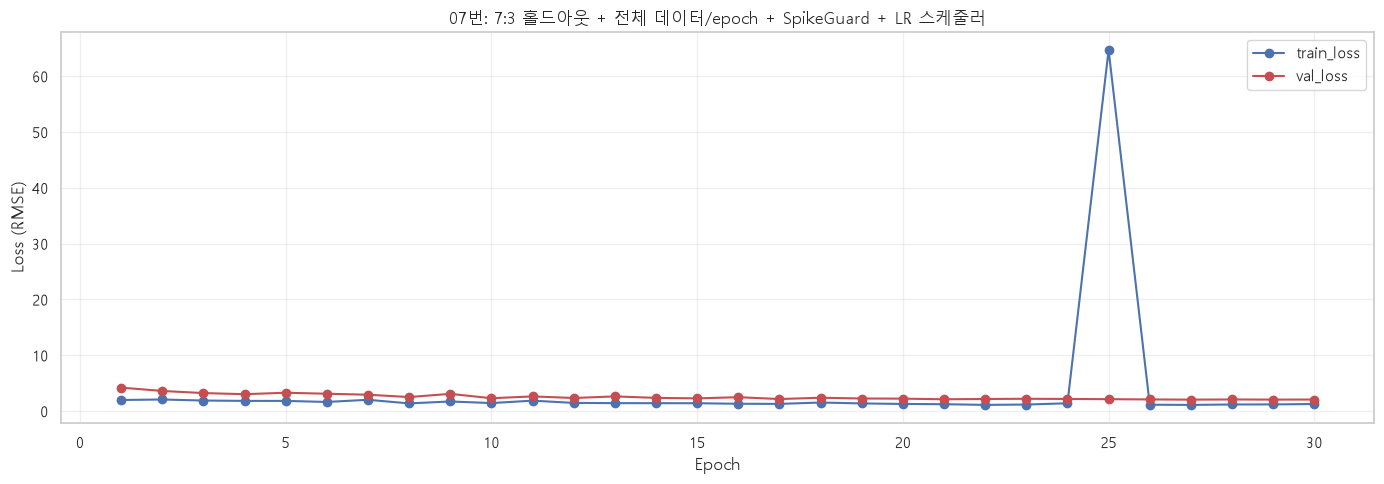

val_loss 변동폭(최대-최소): 2.157  (참고: 03번 18.068 / 06번 0.79)


In [10]:
hist_df = pd.DataFrame(progress_callback.history)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train_loss", color="#4C72B0")
ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="val_loss", color="#C44E52")
for ep in spike_guard_callback.fired_epochs:
    ax.axvline(ep, color="orange", linestyle="--", alpha=0.7,
               label="SpikeGuard 개입" if ep == spike_guard_callback.fired_epochs[0] else None)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (RMSE)")
ax.set_title("07번: 7:3 홀드아웃 + 전체 데이터/epoch + SpikeGuard + LR 스케줄러")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/07_holdout_training_curve.png", dpi=120)
plt.show()

val_loss_range = hist_df["val_loss"].max() - hist_df["val_loss"].min()
print(f"val_loss 변동폭(최대-최소): {val_loss_range:.3f}  (참고: 03번 18.068 / 06번 0.79)")


## 8. N-HiTS threshold 보정 — validation 잔차만으로 결정 (test 미사용)

베이스라인과 동일한 원칙입니다: validation(정상 데이터)의 오탐률만 보고 threshold를
정하고, test는 아직 열지 않습니다.


In [11]:
def one_step_residuals(df_raw, training_dataset, model):
    """원본 행 하나당 '한 스텝 뒤' 예측값 1개를 매칭해 잔차를 계산한다.
    (윈도우가 겹치는 구조이므로, 각 윈도우의 첫 번째 디코더 스텝 예측만 사용해서
    실제 시점과 1:1로 정렬한다.)"""
    df = adjust(df_raw)
    ds = TimeSeriesDataSet.from_dataset(training_dataset, df, predict=False, stop_randomization=True)
    dl = ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    result = model.predict(
        dl, mode="prediction", return_index=True, return_y=True,
        trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, enable_progress_bar=False, logger=False),
    )
    preds = result.output.cpu().numpy()
    idx_df = result.index
    actuals = result.y[0].cpu().numpy()
    out = pd.DataFrame({
        "time_idx": idx_df["time_idx"].values,
        "actual": actuals[:, 0],
        "pred": preds[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    out["residual"] = out["actual"] - out["pred"]
    return out


# validation(뒤 30%, 정상 데이터)로 잔차 기준(평균/표준편차) 계산
# val_raw 앞부분에 encoder 워밍업(20행)을 붙여줘야 첫 예측부터 검증셋 시작점을 커버한다.
val_window = train_full[train_full["time_idx"] > training_cutoff - max_encoder_length] \
    .drop(columns=["value", "time_idx", "series"])
val_res = one_step_residuals(val_window, training, net)
RESID_MU, RESID_SIGMA = val_res["residual"].mean(), val_res["residual"].std()
print(f"검증 잔차: mean={RESID_MU:.3f}, std={RESID_SIGMA:.3f}, n={len(val_res)}")
print(f"검증 MAE: {val_res['residual'].abs().mean():.3f}")

# threshold sweep: validation 오탐률만 보고 결정 (test는 아직 절대 사용하지 않음)
print()
for th in [3.0, 4.0, 5.0, 6.0, 8.0]:
    z = (val_res["residual"] - RESID_MU) / RESID_SIGMA
    pred = (z.abs() > th).astype(int).values
    fp_rate = 100 * pred.sum() / len(pred)
    print(f"threshold={th}: validation(정상) 오탐률 = {fp_rate:.3f}% ({pred.sum()}/{len(pred)}건)")

NHITS_THRESHOLD = 6.0  # validation 오탐률이 0%에 가까워지는 지점을 기준으로 채택 (test 미참조)
print(f"\n채택한 N-HiTS threshold = {NHITS_THRESHOLD} (validation 오탐률 기준, test는 보지 않음)")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


검증 잔차: mean=-0.417, std=1.913, n=40719
검증 MAE: 1.417

threshold=3.0: validation(정상) 오탐률 = 1.181% (481/40719건)
threshold=4.0: validation(정상) 오탐률 = 0.420% (171/40719건)
threshold=5.0: validation(정상) 오탐률 = 0.295% (120/40719건)
threshold=6.0: validation(정상) 오탐률 = 0.187% (76/40719건)
threshold=8.0: validation(정상) 오탐률 = 0.106% (43/40719건)

채택한 N-HiTS threshold = 6.0 (validation 오탐률 기준, test는 보지 않음)


## 9. 앙상블 결합 함수 정의 (원칙만 정하고, 실제 비교는 마지막에)

`docs/도메인_배경지식.md`에 정리된 대로 예지보전에서는 이상을 놓치는 것(False Negative)이
오탐(False Positive)보다 훨씬 치명적입니다. 이 원칙에 따라 **OR 앙상블을 기본으로 채택**하고,
`AND` 앙상블은 참고 비교용으로 함께 계산합니다. (이 선택은 test 성능을 보고 정한 것이 아니라,
test를 열기 전에 이미 정해둔 도메인 원칙입니다.)


In [12]:
def ensemble_predict(baseline_pred_arr, nhits_pred_series, n, mode="or"):
    """베이스라인 예측과 N-HiTS 예측을 결합한다.
    mode='or'  : 둘 중 하나라도 이상이면 이상 (재현율 우선 - 기본값, FN을 줄이는 방향)
    mode='and' : 둘 다 이상이어야 이상 (정밀도 우선 - 참고 비교용)
    N-HiTS 점수가 없는 행(인코더 워밍업 구간)은 베이스라인 예측을 그대로 사용한다."""
    combined = baseline_pred_arr.copy()
    scored_idx = nhits_pred_series.index.values
    b = baseline_pred_arr[scored_idx]
    h = nhits_pred_series.values
    if mode == "or":
        combined[scored_idx] = np.maximum(b, h)
    elif mode == "and":
        combined[scored_idx] = np.minimum(b, h)
    else:
        raise ValueError(f"unknown mode: {mode}")
    return combined

ENSEMBLE_PRIMARY_MODE = "or"  # 도메인 원칙(FN 최소화)에 따른 기본 선택. "and"는 비교용으로만 참고.
print(f"앙상블 기본 결합 방식: {ENSEMBLE_PRIMARY_MODE.upper()} (FN을 줄이는 방향, test 성능을 보고 정한 것이 아님)")


앙상블 기본 결합 방식: OR (FN을 줄이는 방향, test 성능을 보고 정한 것이 아님)


## 10. ⚠️ 최종 테스트 평가 — 여기서 처음으로 test 데이터를 엽니다

지금까지의 모든 결정(베이스라인 규칙, threshold=4.0/6.0, N-HiTS 하이퍼파라미터, 앙상블
결합 방식)은 `WeldingTest_*.csv`를 단 한 번도 열어보지 않고 train/validation만으로
정했습니다. 아래 셀에서 `TEST_DATA_UNLOCKED = True`로 바꾼 뒤 처음이자 마지막으로 test
데이터를 불러와 3개 모델(베이스라인 / N-HiTS / 앙상블)을 한 번에 평가합니다.


In [13]:
TEST_DATA_UNLOCKED = True
print("테스트 데이터를 처음으로 불러옵니다. (지금까지 어떤 모델 설계·threshold 결정에도 사용되지 않았습니다.)")

test_sets = {
    "test01_OK": (load_test_csv(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"), None),
    "test02_OK": (load_test_csv(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"), None),
    "test03_NG": (load_test_csv(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"]),
    "test04_NG": (load_test_csv(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"]),
}
for name, (df, label) in test_sets.items():
    print(f"{name}: shape={df.shape}")


테스트 데이터를 처음으로 불러옵니다. (지금까지 어떤 모델 설계·threshold 결정에도 사용되지 않았습니다.)
test01_OK: shape=(1950, 9)
test02_OK: shape=(1872, 9)
test03_NG: shape=(1053, 9)
test04_NG: shape=(351, 9)


In [14]:
def eval_metrics(pred, label):
    """이진 예측(pred)과 실제 라벨(label)을 비교해 accuracy/precision/recall/f1을 계산한다.
    label이 None이면(정상 테스트셋) 오탐 개수/비율만 반환한다."""
    n = len(pred)
    out = {"n_scored": n, "n_flagged": int(pred.sum())}
    if label is not None:
        gt = label.values
        acc = accuracy_score(gt, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
        cm = confusion_matrix(gt, pred)
        out.update(accuracy=acc, precision=precision, recall=recall, f1=f1, confusion_matrix=cm)
    return out


final_rows = {}
nhits_full_pred = {}
baseline_pred_full = {}
ensemble_or_full = {}
ensemble_and_full = {}

for name, (df, label) in test_sets.items():
    # 1) 베이스라인
    b_pred, b_z, b_reason = score_baseline(df, group_stats, KNOWN_SETPOWERS, threshold=BASELINE_THRESHOLD)
    baseline_pred_full[name] = b_pred

    # 2) N-HiTS (인코더 워밍업 구간은 점수가 없으므로 '정상(0)'으로 채워 전체 길이를 맞춘다)
    res = one_step_residuals(df, training, net)
    z = (res["residual"] - RESID_MU) / RESID_SIGMA
    h_pred_scored = pd.Series((z.abs() > NHITS_THRESHOLD).astype(int).values, index=res["time_idx"].values)
    h_pred_full = np.zeros(len(df), dtype=int)
    h_pred_full[h_pred_scored.index.values] = h_pred_scored.values
    nhits_full_pred[name] = h_pred_full

    # 3) 앙상블 (OR 기본 + AND 참고) — 나중에 시각화에서도 재사용할 수 있도록 결과 배열 자체를 저장한다
    ens_or = ensemble_predict(b_pred, h_pred_scored, len(df), mode="or")
    ens_and = ensemble_predict(b_pred, h_pred_scored, len(df), mode="and")
    ensemble_or_full[name] = ens_or
    ensemble_and_full[name] = ens_and

    final_rows[(name, "베이스라인")] = eval_metrics(b_pred, label)
    final_rows[(name, "N-HiTS")] = eval_metrics(h_pred_full, label)
    final_rows[(name, "앙상블(OR, 기본)")] = eval_metrics(ens_or, label)
    final_rows[(name, "앙상블(AND, 참고)")] = eval_metrics(ens_and, label)

    print(f"=== {name} ===")
    for model_name in ["베이스라인", "N-HiTS", "앙상블(OR, 기본)", "앙상블(AND, 참고)"]:
        r = final_rows[(name, model_name)]
        if "accuracy" in r:
            print(f"  {model_name:16s} Acc={r['accuracy']:.4f} P={r['precision']:.4f} "
                  f"R={r['recall']:.4f} F1={r['f1']:.4f}")
        else:
            print(f"  {model_name:16s} 오탐 {r['n_flagged']}/{r['n_scored']} "
                  f"({100*r['n_flagged']/r['n_scored']:.2f}%)")
    print()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

=== test01_OK ===
  베이스라인            오탐 0/1950 (0.00%)
  N-HiTS           오탐 0/1950 (0.00%)
  앙상블(OR, 기본)      오탐 0/1950 (0.00%)
  앙상블(AND, 참고)     오탐 0/1950 (0.00%)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== test02_OK ===
  베이스라인            오탐 0/1872 (0.00%)
  N-HiTS           오탐 0/1872 (0.00%)
  앙상블(OR, 기본)      오탐 0/1872 (0.00%)
  앙상블(AND, 참고)     오탐 0/1872 (0.00%)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== test03_NG ===
  베이스라인            Acc=0.9981 P=0.9048 R=1.0000 F1=0.9500
  N-HiTS           Acc=0.8936 P=0.1395 R=0.9474 F1=0.2432
  앙상블(OR, 기본)      Acc=0.8927 P=0.1439 R=1.0000 F1=0.2517
  앙상블(AND, 참고)     Acc=1.0000 P=1.0000 R=1.0000 F1=1.0000

=== test04_NG ===
  베이스라인            Acc=0.9886 P=0.9856 R=1.0000 F1=0.9927
  N-HiTS           Acc=0.9117 P=0.9549 R=0.9304 F1=0.9425
  앙상블(OR, 기본)      Acc=0.9544 P=0.9446 R=1.0000 F1=0.9715
  앙상블(AND, 참고)     Acc=0.9630 P=0.9887 R=0.9634 F1=0.9759



## 11. 최종 비교표 저장

이전 노트북들의 `outputs/model_comparison.csv`와 방법론(홀드아웃 분리)이 다르므로, 혼동을
피하기 위해 **별도 파일**(`model_comparison_07_holdout.csv`)로 저장합니다.


In [15]:
compare_cols = {}
for (name, model_name), r in final_rows.items():
    if "accuracy" not in r:
        continue
    for metric in ["accuracy", "precision", "recall", "f1"]:
        compare_cols[(model_name, metric)] = compare_cols.get((model_name, metric), {})
        compare_cols[(model_name, metric)][name] = r[metric]

final_comparison = pd.DataFrame(compare_cols)
final_comparison.columns = pd.MultiIndex.from_tuples(final_comparison.columns)
final_comparison = final_comparison.loc[["test03_NG", "test04_NG"]]
final_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison_07_holdout.csv")
final_comparison


베이스라인                               N-HiTS                      \
           accuracy precision recall        f1  accuracy precision    recall   
test03_NG  0.998101  0.904762    1.0  0.950000  0.893637  0.139535  0.947368   
test04_NG  0.988604  0.985560    1.0  0.992727  0.911681  0.954887  0.930403   

                    앙상블(OR, 기본)                            앙상블(AND, 참고)  \
                 f1    accuracy precision recall        f1     accuracy   
test03_NG  0.243243    0.892688  0.143939    1.0  0.251656     1.000000   
test04_NG  0.942486    0.954416  0.944637    1.0  0.971530     0.962963   

                                        
          precision   recall        f1  
test03_NG  1.000000  1.00000  1.000000  
test04_NG  0.988722  0.96337  0.975881

In [16]:
print("정상 테스트 데이터(test01/02_OK)에서의 오탐률 (validation 기준으로 정한 threshold가 실제로도 유효한지 확인):")
for name in ["test01_OK", "test02_OK"]:
    n = len(test_sets[name][0])
    b_fp = final_rows[(name, "베이스라인")]["n_flagged"]
    h_fp = final_rows[(name, "N-HiTS")]["n_flagged"]
    or_fp = final_rows[(name, "앙상블(OR, 기본)")]["n_flagged"]
    and_fp = final_rows[(name, "앙상블(AND, 참고)")]["n_flagged"]
    print(f"  {name}: 베이스라인={b_fp}({100*b_fp/n:.2f}%) N-HiTS={h_fp}({100*h_fp/n:.2f}%) "
          f"OR앙상블={or_fp}({100*or_fp/n:.2f}%) AND앙상블={and_fp}({100*and_fp/n:.2f}%)")


정상 테스트 데이터(test01/02_OK)에서의 오탐률 (validation 기준으로 정한 threshold가 실제로도 유효한지 확인):
  test01_OK: 베이스라인=0(0.00%) N-HiTS=0(0.00%) OR앙상블=0(0.00%) AND앙상블=0(0.00%)
  test02_OK: 베이스라인=0(0.00%) N-HiTS=0(0.00%) OR앙상블=0(0.00%) AND앙상블=0(0.00%)


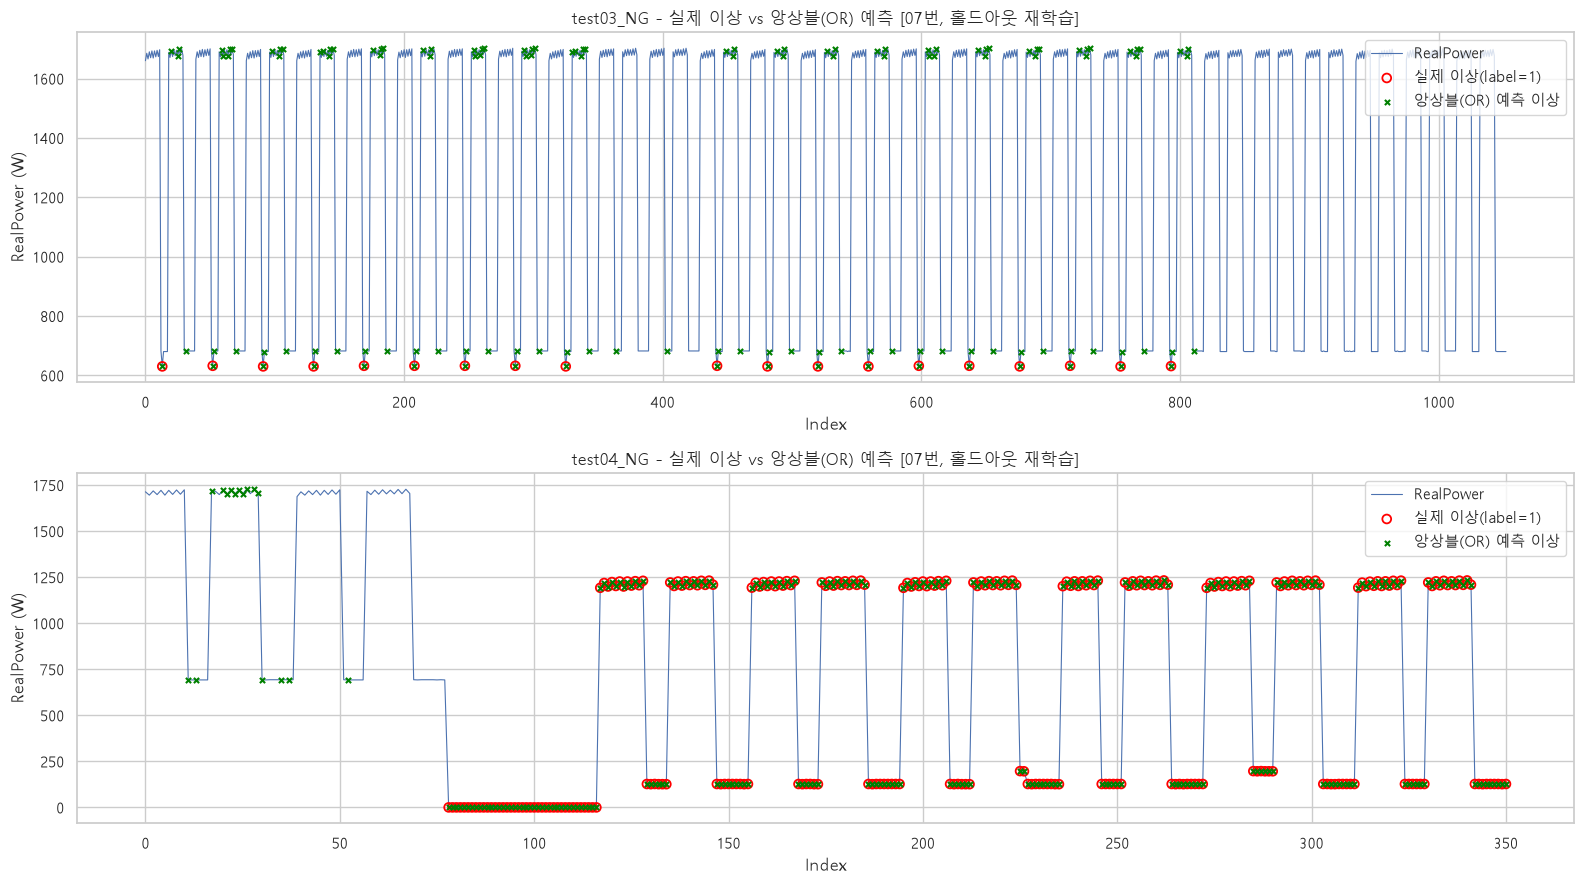

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, name in zip(axes, ["test03_NG", "test04_NG"]):
    df, label = test_sets[name]
    ens_or = ensemble_or_full[name]  # 앞 10장에서 저장해 둔 배열을 그대로 재사용 (재계산하지 않음)

    ax.plot(df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower", zorder=1)
    gt = label.values
    gt_idx = np.where(gt == 1)[0]
    pred_idx = np.where(ens_or == 1)[0]
    ax.scatter(gt_idx, df["RealPower"].values[gt_idx], color="red", s=40, marker="o",
               facecolors="none", linewidths=1.3, label="실제 이상(label=1)", zorder=3)
    ax.scatter(pred_idx, df["RealPower"].values[pred_idx], color="green", s=14, marker="x",
               label="앙상블(OR) 예측 이상", zorder=4)
    ax.set_title(f"{name} - 실제 이상 vs 앙상블(OR) 예측 [07번, 홀드아웃 재학습]")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/07_holdout_prediction_vs_truth.png", dpi=120)
plt.show()


## 12. 결과 해석 가이드

이 표의 수치는 이전 노트북들과 달리 **test 데이터를 전혀 들여다보지 않고** 결정한 규칙/
threshold/하이퍼파라미터로 얻은 결과입니다. 실행 후 다음을 확인하세요.

- **test01/02_OK 오탐률(11장)**: validation만으로 정한 threshold가 test에서도 낮은 오탐률을
  유지한다면, threshold 선택이 특정 테스트 파일에 과적합되지 않고 잘 일반화된다는 뜻입니다.
- **이전 노트북 대비 F1이 다소 낮아졌을 수 있습니다.** 예를 들어 베이스라인의 SetPower=35
  규칙 자체는 그대로지만, N-HiTS threshold(6.0)는 이번엔 test03/04_NG의 F1을 최대화하도록
  고른 게 아니라 validation 오탐률만 보고 골랐기 때문입니다. **이 수치가 오히려 더 정직한
  일반화 성능 추정치**입니다 — 이전 1.0에 가까운 수치들은 test를 반복해서 보며 얻은
  낙관적인 결과였다는 점을 상기하세요 (1차 종합보고서 및 대화 기록 참고).
- **학습 곡선(7장)의 val_loss 변동폭**을 03번(18.068)·06번(0.79)과 비교해, SpikeGuard +
  patience 재조정이 실제로 더 안정적인지 확인하세요.
- 세 모델(베이스라인/N-HiTS/앙상블) 중 어느 것이 가장 균형 잡힌 성능을 보이는지, 그리고
  OR 앙상블과 AND 앙상블 중 어느 쪽이 이번 홀드아웃 평가에서도 여전히 유효한 선택인지
  비교해 보세요.
